# Plot Figure 7A-F

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load datasets
dataPCA = pd.read_csv('load pca.csv')
data_firing = pd.read_csv('load single_unit.csv')
data_avg = pd.read_csv('load unit_pair_avg.csv')
data_lag = pd.read_csv('load lag_data.csv')
data_dim = pd.read_csv('load dimensions.csv')
# set firing rate to log10
data_firing.firing_rate = np.log10(data_firing.firing_rate)
# make two custom palettes
palette0 = {'backbone': '#21409a', 'non-rigid': '#f7941d'}
palette1 = {'non-rigid - non-rigid': '#f7941d',
            'backbone - non-rigid': '#939598',
            'backbone - backbone': '#21409a'}

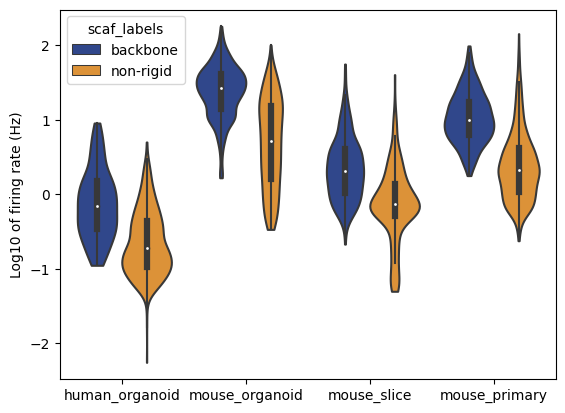

In [2]:
# plot firing rate
plt.figure()
fig = sns.violinplot(x='sample_type', y='firing_rate', hue='scaf_labels',
                     data=data_firing, cut=0, scale='area',
                     hue_order=['backbone', 'non-rigid'], palette=palette0)
plt.xlabel('')
plt.ylabel('Log10 of firing rate (Hz)');

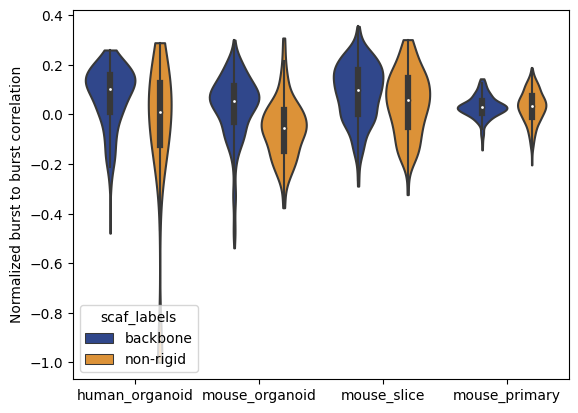

In [3]:
# plot burst to burst correlation
plt.figure()
fig = sns.violinplot(x='sample_type', y='btb_corr_m', hue='scaf_labels',
                     data=data_firing, cut=0, scale='area',
                     hue_order=['backbone', 'non-rigid'], palette=palette0)
plt.xlabel('')
plt.ylabel('Normalized burst to burst correlation');

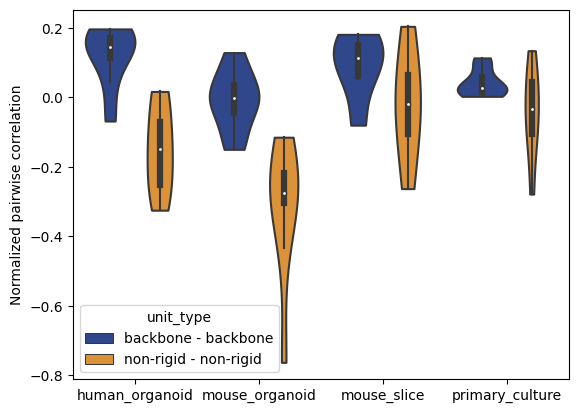

In [4]:
# plot average pairwise correlations
plt.figure()
fig = sns.violinplot(
    x='sample_type', y='med_corr', hue='unit_type',
    data=data_avg, cut=0, scale='area',
    order=['human_organoid', 'mouse_organoid', 'mouse_slice', 'primary_culture'],
    hue_order=['backbone - backbone', 'non-rigid - non-rigid'],
    palette=palette1
)
plt.xlabel('')
plt.ylabel('Normalized pairwise correlation');

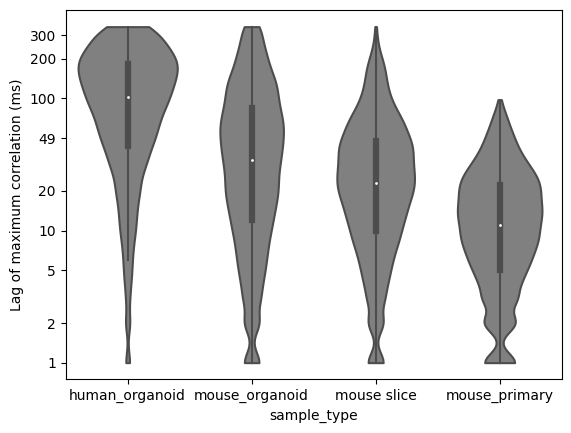

In [5]:
plt.figure()
fig = sns.violinplot(
    x='sample_type', y='lag_vals_log', density_norm='width',
    cut=0, data=data_lag, color='gray')
plt.ylabel('Lag of maximum correlation (ms)')

# Define tick values and corresponding labels
tick_vals = np.log10([1, 2, 5, 10, 20, 50, 100, 200, 300])
tick_labels = [str(int(10**val)) for val in tick_vals]

plt.yticks(tick_vals, tick_labels);

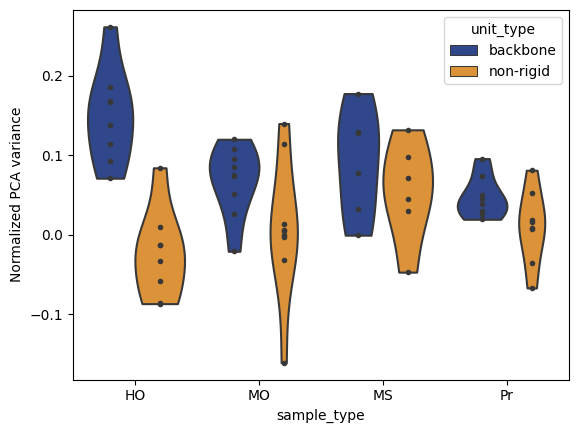

In [6]:
# plot normalized PCa variance
plt.figure()
fig = sns.violinplot(x='sample_type', y='m_value', density_norm='width', cut=0,
                     hue='unit_type', inner='point', data=dataPCA, palette=palette0)
plt.ylabel('Normalized PCA variance');

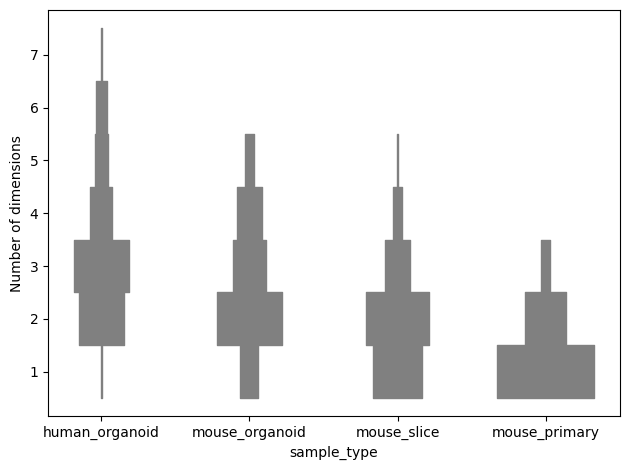

In [7]:
def stepped_violin(df, category_col, value_col):
    fig, ax = plt.subplots()    
    categories = df[category_col].unique()
    positions = range(len(categories))

    for pos, cat in zip(positions, categories):
        cat_data = df[df[category_col] == cat][value_col]
        counts = cat_data.value_counts(normalize=True).sort_index()
        
        for value, proportion in counts.items():
            ax.fill_betweenx(
                [value - 0.5, value + 0.5],  # Vertical span
                [pos - proportion / 2, pos - proportion / 2],  # Left
                [pos + proportion / 2, pos + proportion / 2],  # Right
                color='gray', step="mid"
            )

    # Styling
    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_xlabel(category_col)
    ax.set_ylabel('Number of dimensions')
    
    return fig, ax

# Call the function
fig, ax = stepped_violin(data_dim, category_col='sample_type', value_col='dims')
plt.tight_layout() 